In [121]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("debajyotipodder/co2-emission-by-vehicles")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/co2-emission-by-vehicles


In [122]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import sklearn as skl 
import seaborn as sns 
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.impute import SimpleImputer
from sklearn import feature_selection
import sklearn.compose as ColumnTransformer
import sklearn.pipeline as Pipeline

plt.style.use('seaborn-v0_8')

In [123]:
import os
print(os.listdir('/kaggle/input/co2-emission-by-vehicles'))

['CO2 Emissions_Canada.csv', 'Data Description.csv']


In [124]:
# DATA_FOLDER = '../data'
DATA_FOLDER = '/kaggle/input/'
DATA_FILE_PATH = os.path.join(DATA_FOLDER, "co2-emission-by-vehicles/CO2 Emissions_Canada.csv")

In [125]:
df = pd.read_csv(DATA_FILE_PATH)
df.head()

,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
0,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244


In [126]:
df.shape

(7385, 12)

In [127]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7385 entries, 0 to 7384
Data columns (total 12 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Make                              7385 non-null   object 
 1   Model                             7385 non-null   object 
 2   Vehicle Class                     7385 non-null   object 
 3   Engine Size(L)                    7385 non-null   float64
 4   Cylinders                         7385 non-null   int64  
 5   Transmission                      7385 non-null   object 
 6   Fuel Type                         7385 non-null   object 
 7   Fuel Consumption City (L/100 km)  7385 non-null   float64
 8   Fuel Consumption Hwy (L/100 km)   7385 non-null   float64
 9   Fuel Consumption Comb (L/100 km)  7385 non-null   float64
 10  Fuel Consumption Comb (mpg)       7385 non-null   int64  
 11  CO2 Emissions(g/km)               7385 non-null   int64  
dtypes: flo

<Axes: xlabel='Engine Size(L)', ylabel='Cylinders'>

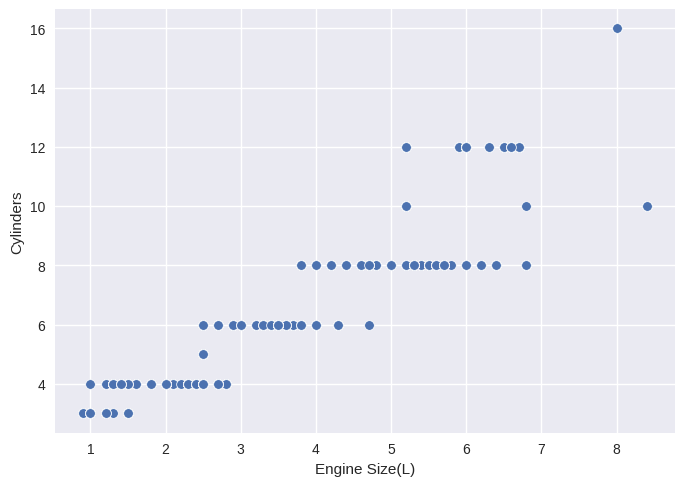

In [128]:
sns.scatterplot(x = df["Engine Size(L)"], y = df["Cylinders"], data = df)

**Engine size** represents the volumne of the cylinders 

**Cyliners** represents the count of those chambers 

**Insight** : As the numbder of cylinder increases, the total displacement(Engine size) almost always increases as well 

**multicollnearity** : Since both features has strong positive correlation, can only keep one featur out of both 

In [129]:
categorical_columns = df.select_dtypes(include = 'object')
numerical_columns = df.select_dtypes(include = ['float64','int64'])

<Axes: >

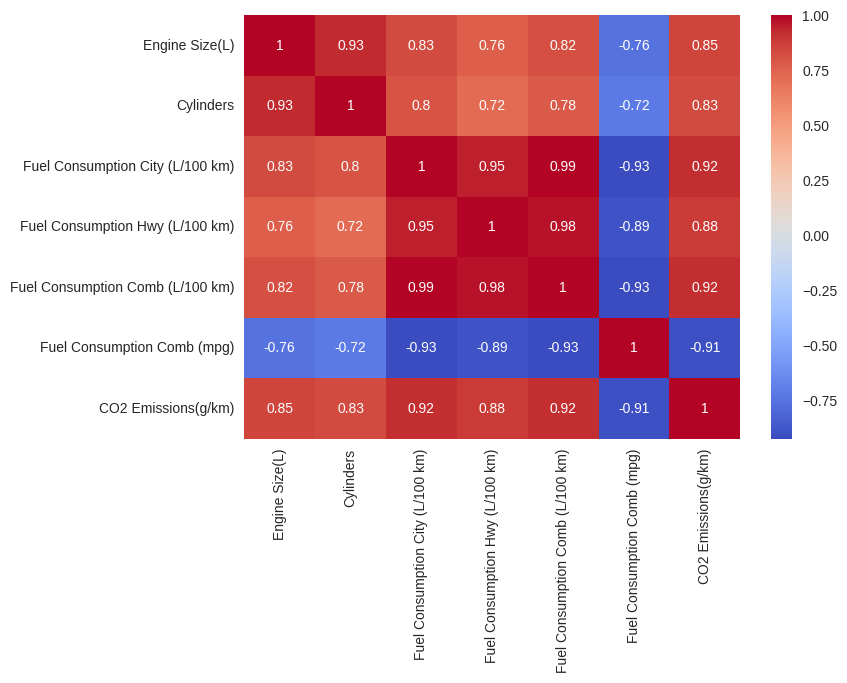

In [130]:
sns.heatmap(numerical_columns.corr(), cmap = "coolwarm", annot = True)

In [131]:
df = df.drop("Cylinders", axis = 1)

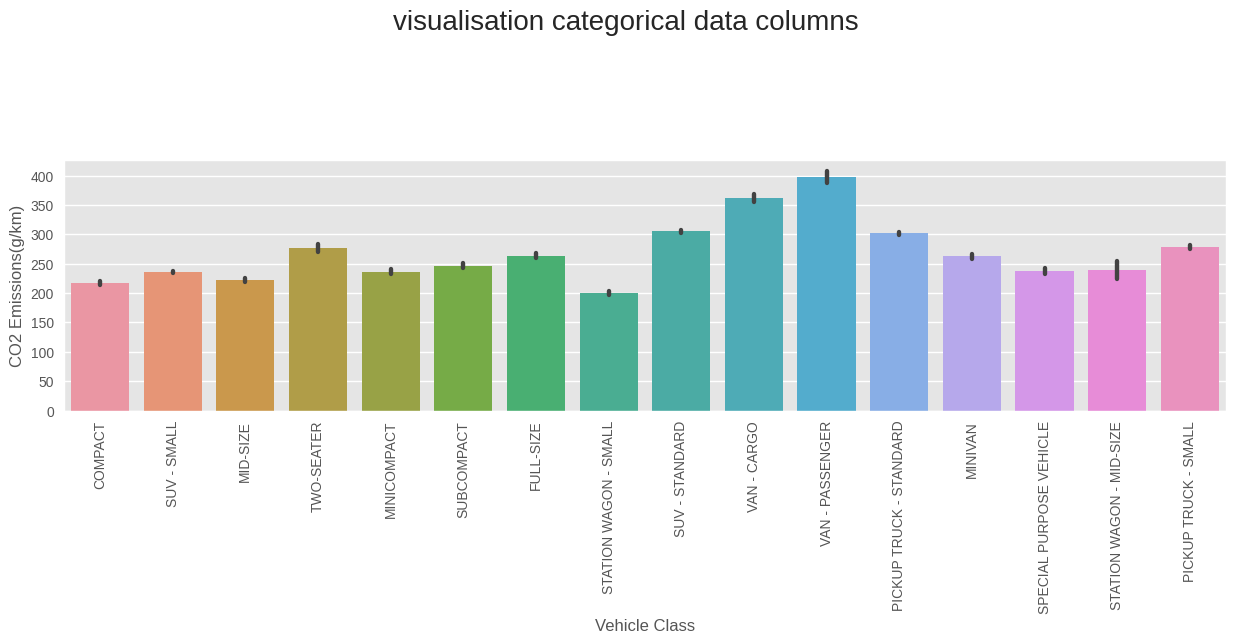

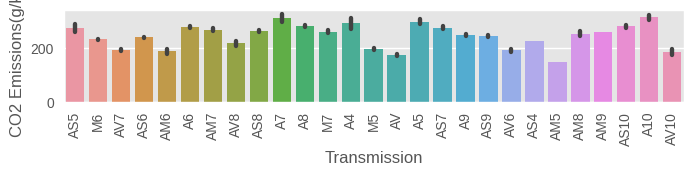

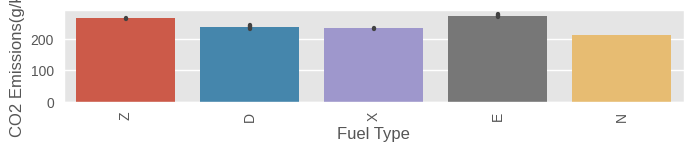

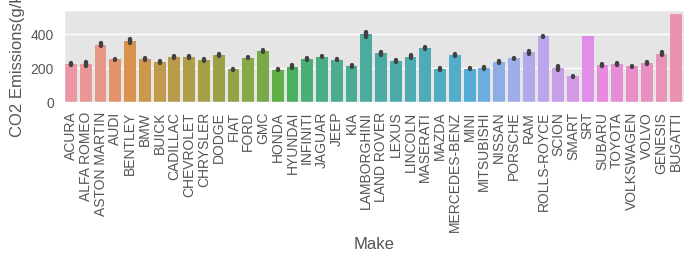

In [132]:
plt.style.use('ggplot')
fig = plt.figure(figsize =(15, 15))
fig.suptitle('visualisation categorical data columns', fontsize = 20)

plt.subplot(4,1,1)
sns.barplot(x = df["Vehicle Class"], y = df["CO2 Emissions(g/km)"], data = df)
plt.xticks(rotation=90)
plt.show()

plt.subplot(4,1,2)
sns.barplot(x = df["Transmission"], y = df["CO2 Emissions(g/km)"], data = df)
plt.xticks(rotation=90)
plt.show()

plt.subplot(4,1,3)
sns.barplot(x = df["Fuel Type"], y = df["CO2 Emissions(g/km)"], data = df)
plt.xticks(rotation=90)
plt.show()

plt.subplot(4,1,4)
sns.barplot(x = df["Make"], y = df["CO2 Emissions(g/km)"], data = df)
plt.xticks(rotation=90)
plt.show()

Highest CO2 emission - categories: 

Make Vs CO2 Emissions(g/km) : Bugatti 

<Axes: xlabel='Make'>

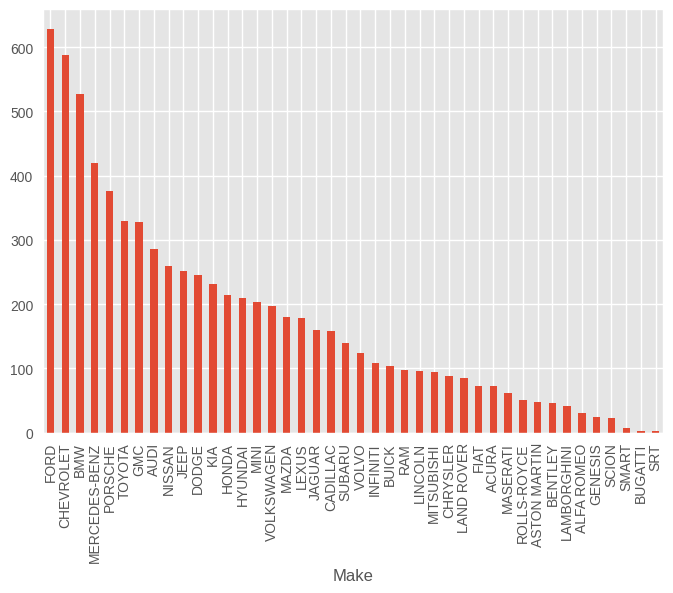

In [133]:
df["Make"].value_counts().plot(kind = "bar")

In [134]:
df["Transmission"].unique()

array(['AS5', 'M6', 'AV7', 'AS6', 'AM6', 'A6', 'AM7', 'AV8', 'AS8', 'A7',
       'A8', 'M7', 'A4', 'M5', 'AV', 'A5', 'AS7', 'A9', 'AS9', 'AV6',
       'AS4', 'AM5', 'AM8', 'AM9', 'AS10', 'A10', 'AV10'], dtype=object)

Transmission: The type of gearbox. The codes usually represent:

A: Automatic

AM: Automated manual

AS: Automatic with select shift

AV: Continuously variable (CVT)

M: Manual

The number following the letters indicates the number of gears (e.g., AS6 = 6 gears).

In [135]:
df_2 = df.copy()

In [136]:
unique_transmission = df_2["Transmission"].unique()
x = {val : i for i, val in enumerate(unique_transmission)}
df_2["Transmission_encoded"] = df_2["Transmission"].map(x)
df_2.head()

,Make,Model,Vehicle Class,Engine Size(L),Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km),Transmission_encoded
0,ACURA,ILX,COMPACT,2.0,AS5,Z,9.9,6.7,8.5,33,196,0
1,ACURA,ILX,COMPACT,2.4,M6,Z,11.2,7.7,9.6,29,221,1
2,ACURA,ILX HYBRID,COMPACT,1.5,AV7,Z,6.0,5.8,5.9,48,136,2
3,ACURA,MDX 4WD,SUV - SMALL,3.5,AS6,Z,12.7,9.1,11.1,25,255,3
4,ACURA,RDX AWD,SUV - SMALL,3.5,AS6,Z,12.1,8.7,10.6,27,244,3


{'AS5': 0,
 'M6': 1,
 'AV7': 2,
 'AS6': 3,
 'AM6': 4,
 'A6': 5,
 'AM7': 6,
 'AV8': 7,
 'AS8': 8,
 'A7': 9,
 'A8': 10,
 'M7': 11,
 'A4': 12,
 'M5': 13,
 'AV': 14,
 'A5': 15,
 'AS7': 16,
 'A9': 17,
 'AS9': 18,
 'AV6': 19,
 'AS4': 20,
 'AM5': 21,
 'AM8': 22,
 'AM9': 23,
 'AS10': 24,
 'A10': 25,
 'AV10': 26}

In [137]:
unique_Vehicle_Class = df_2["Vehicle Class"].unique()
x = {val : i for i, val in enumerate(unique_Vehicle_Class)}
df_2["Vehicle_Class_encoded"] = df_2["Vehicle Class"].map(x)
df_2.head()

,Make,Model,Vehicle Class,Engine Size(L),Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km),Transmission_encoded,Vehicle_Class_encoded
0,ACURA,ILX,COMPACT,2.0,AS5,Z,9.9,6.7,8.5,33,196,0,0
1,ACURA,ILX,COMPACT,2.4,M6,Z,11.2,7.7,9.6,29,221,1,0
2,ACURA,ILX HYBRID,COMPACT,1.5,AV7,Z,6.0,5.8,5.9,48,136,2,0
3,ACURA,MDX 4WD,SUV - SMALL,3.5,AS6,Z,12.7,9.1,11.1,25,255,3,1
4,ACURA,RDX AWD,SUV - SMALL,3.5,AS6,Z,12.1,8.7,10.6,27,244,3,1


{'COMPACT': 0,
 'SUV - SMALL': 1,
 'MID-SIZE': 2,
 'TWO-SEATER': 3,
 'MINICOMPACT': 4,
 'SUBCOMPACT': 5,
 'FULL-SIZE': 6,
 'STATION WAGON - SMALL': 7,
 'SUV - STANDARD': 8,
 'VAN - CARGO': 9,
 'VAN - PASSENGER': 10,
 'PICKUP TRUCK - STANDARD': 11,
 'MINIVAN': 12,
 'SPECIAL PURPOSE VEHICLE': 13,
 'STATION WAGON - MID-SIZE': 14,
 'PICKUP TRUCK - SMALL': 15}

In [138]:
unique_Fuel_Type = df_2["Fuel Type"].unique()
x = {val : i for i, val in enumerate(unique_Fuel_Type)}
df_2["Fuel_Type_encoded"] = df_2["Fuel Type"].map(x)
df_2.head()

,Make,Model,Vehicle Class,Engine Size(L),Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km),Transmission_encoded,Vehicle_Class_encoded,Fuel_Type_encoded
0,ACURA,ILX,COMPACT,2.0,AS5,Z,9.9,6.7,8.5,33,196,0,0,0
1,ACURA,ILX,COMPACT,2.4,M6,Z,11.2,7.7,9.6,29,221,1,0,0
2,ACURA,ILX HYBRID,COMPACT,1.5,AV7,Z,6.0,5.8,5.9,48,136,2,0,0
3,ACURA,MDX 4WD,SUV - SMALL,3.5,AS6,Z,12.7,9.1,11.1,25,255,3,1,0
4,ACURA,RDX AWD,SUV - SMALL,3.5,AS6,Z,12.1,8.7,10.6,27,244,3,1,0


X: Regular gasoline

Z: Premium gasoline

D: Diesel

E: Ethanol (E85)

N: Natural gas

{'Z': 0, 'D': 1, 'X': 2, 'E': 3, 'N': 4}

In [139]:
df_2.drop(columns = ["Transmission","Fuel Type","Vehicle Class","Model","Make"], axis = 1, inplace =True)

In [140]:
df_2.sample(5)

,Engine Size(L),Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km),Transmission_encoded,Vehicle_Class_encoded,Fuel_Type_encoded
706,1.5,8.0,6.7,7.4,38,170,13,0,2
6171,4.0,15.0,10.9,13.2,21,309,17,1,0
4653,6.2,17.6,10.7,14.5,19,339,10,2,0
588,3.6,17.7,13.0,15.6,18,250,10,8,3
1147,2.0,11.7,8.5,10.2,28,235,4,3,0


In [141]:
df_2.columns

Index(['Engine Size(L)', 'Fuel Consumption City (L/100 km)',
       'Fuel Consumption Hwy (L/100 km)', 'Fuel Consumption Comb (L/100 km)',
       'Fuel Consumption Comb (mpg)', 'CO2 Emissions(g/km)',
       'Transmission_encoded', 'Vehicle_Class_encoded', 'Fuel_Type_encoded'],
      dtype='object')

In [142]:
df_2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7385 entries, 0 to 7384
Data columns (total 9 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Engine Size(L)                    7385 non-null   float64
 1   Fuel Consumption City (L/100 km)  7385 non-null   float64
 2   Fuel Consumption Hwy (L/100 km)   7385 non-null   float64
 3   Fuel Consumption Comb (L/100 km)  7385 non-null   float64
 4   Fuel Consumption Comb (mpg)       7385 non-null   int64  
 5   CO2 Emissions(g/km)               7385 non-null   int64  
 6   Transmission_encoded              7385 non-null   int64  
 7   Vehicle_Class_encoded             7385 non-null   int64  
 8   Fuel_Type_encoded                 7385 non-null   int64  
dtypes: float64(4), int64(5)
memory usage: 519.4 KB


In [143]:
df_2.shape

(7385, 9)

<Axes: >

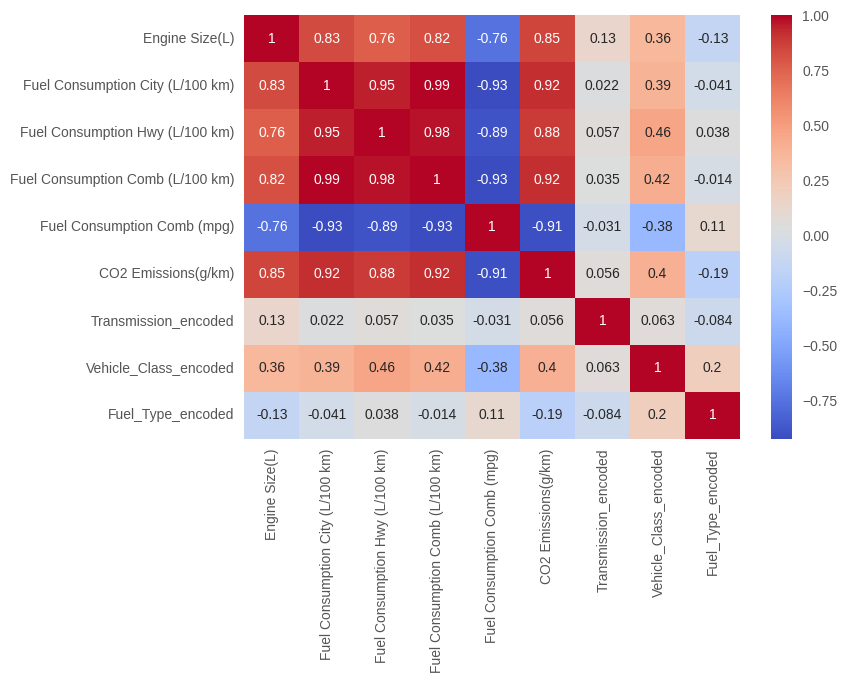

In [144]:
sns.heatmap(df_2.corr(), annot= True, cmap = "coolwarm")

In [145]:
from scipy.stats import pearsonr
target = 'CO2 Emissions(g/km)'
for col in df_2.columns:
    if col != target and df_2[col].nunique() > 1:
        r, p = pearsonr(df_2[col], df_2[target])
        print(f"{col}: correlation={r:.3f}, p-value={p:.3e}")

Engine Size(L): correlation=0.851, p-value=0.000e+00
Fuel Consumption City (L/100 km): correlation=0.920, p-value=0.000e+00
Fuel Consumption Hwy (L/100 km): correlation=0.884, p-value=0.000e+00
Fuel Consumption Comb (L/100 km): correlation=0.918, p-value=0.000e+00
Fuel Consumption Comb (mpg): correlation=-0.907, p-value=0.000e+00
Transmission_encoded: correlation=0.056, p-value=1.378e-06
Vehicle_Class_encoded: correlation=0.402, p-value=2.956e-285
Fuel_Type_encoded: correlation=-0.193, p-value=3.790e-63


1. Top Predictors (Strong Correlation)
Features with an "r" value greater than 0.8 indicate a strong linear relationship, showing that CO2 emissions are highly dependent on these variables:

Fuel Consumption City (0.920) & Combined (0.918): These are the most significantly correlated features. This indicates that as a vehicle's fuel consumption increases (especially in city driving), the CO2 emissions rise almost proportionally.

Engine Size (0.851): This is also a strong predictor. A larger engine displacement typically leads to higher fuel consumption, which in turn results in higher CO2 emissions.

Now check multicolinearity 

In [146]:
from scipy.stats import pearsonr

for target in df_2.columns:
    targets = target
    print(targets)
    for col in df_2.columns:
        if col != target and df_2[col].nunique() > 1:
            r, p = pearsonr(df_2[col], df_2[target])
            print(f"{col}: correlation={r:.3f}, p-value={p:.3e}")

Engine Size(L)
Fuel Consumption City (L/100 km): correlation=0.831, p-value=0.000e+00
Fuel Consumption Hwy (L/100 km): correlation=0.762, p-value=0.000e+00
Fuel Consumption Comb (L/100 km): correlation=0.817, p-value=0.000e+00
Fuel Consumption Comb (mpg): correlation=-0.758, p-value=0.000e+00
CO2 Emissions(g/km): correlation=0.851, p-value=0.000e+00
Transmission_encoded: correlation=0.130, p-value=2.082e-29
Vehicle_Class_encoded: correlation=0.357, p-value=3.033e-220
Fuel_Type_encoded: correlation=-0.132, p-value=6.052e-30
Fuel Consumption City (L/100 km)
Engine Size(L): correlation=0.831, p-value=0.000e+00
Fuel Consumption Hwy (L/100 km): correlation=0.948, p-value=0.000e+00
Fuel Consumption Comb (L/100 km): correlation=0.994, p-value=0.000e+00
Fuel Consumption Comb (mpg): correlation=-0.927, p-value=0.000e+00
CO2 Emissions(g/km): correlation=0.920, p-value=0.000e+00
Transmission_encoded: correlation=0.022, p-value=6.157e-02
Vehicle_Class_encoded: correlation=0.388, p-value=6.660e-264

High Multicollinearity : the most striking observation is the extreme redundancy among the fuel consumption metrices.
- Fuel Consumpton City vs. combined: correlation of 0.994 is nearly pefect
- fuel Consumpiton Hwy vs. combined: corrlation of 0.977

Weak or non-linear Predictors 
- transmission_encoded (r = 0.056): the type of geabox has almost no direct linear impact on CO2 emissions in this dataset.
- Fuel_type_encoded(r = -0.193): while there is some relationship, type of fuel (Ethanol vs. Diesal vs.Gas) doesn't corrlated strogly in a linear fastion with row emmission number compared to how much fuel is actually being burnd. 

In [147]:
X = df_2[["Engine Size(L)"]]
y = df_2["CO2 Emissions(g/km)"]
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.3, random_state = 42)

In [148]:
lr = LinearRegression()
model = lr.fit(X_train, y_train)

In [149]:
predictions = model.predict(X_test)
print(f"Intercept: {model.intercept_}")
print(f"Coefficients: {model.coef_}")

Intercept: 134.87184625585314
Coefficients: [36.67696432]


In [150]:
# Error evaluation
print('Mean Absolute Error:', mean_absolute_error(y_test, predictions))
print('Mean Squared Error:', mean_squared_error(y_test, predictions))
print('Root Mean Squared Error:', np.sqrt(mean_squared_error(y_test, predictions)))
print('R2 Score:', r2_score(y_test, predictions))

Mean Absolute Error: 23.073809826866405
Mean Squared Error: 939.4403331445467
Root Mean Squared Error: 30.65029091451738
R2 Score: 0.7218702688223468


**Insights from Data**

Based on the correlation analysis you performed earlier in the notebook:

**Engine Size** is a strong predictor (r = 0.851), but Fuel Consumption City is actually your strongest predictor (r = 0.920).

**Multicollinearity**: correctly identified that the various Fuel Consumption columns are nearly identical **(r > 0.99)**. Using all of them at once would be redundant, but switching your X variable from Engine Size(L) to Fuel Consumption Comb (L/100 km) would likely immediately boost your R^2 score.

In [151]:
df_2["CO2 Emissions(g/km)"].describe()

count    7385.000000
mean      250.584699
std        58.512679
min        96.000000
25%       208.000000
50%       246.000000
75%       288.000000
max       522.000000
Name: CO2 Emissions(g/km), dtype: float64

In [152]:
X = df_2[["Fuel Consumption City (L/100 km)"]]
y = df_2["CO2 Emissions(g/km)"]
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.3, random_state = 42)

In [153]:
lr = LinearRegression()
model = lr.fit(X_train, y_train)

In [154]:
predictions = model.predict(X_test)
print(f"Intercept: {model.intercept_}")
print(f"Coefficients: {model.coef_}")

Intercept: 57.4698080812974
Coefficients: [15.39030001]


In [155]:
# Error evaluation
print('Mean Absolute Error:', mean_absolute_error(y_test, predictions))
print('Mean Squared Error:', mean_squared_error(y_test, predictions))
print('Root Mean Squared Error:', np.sqrt(mean_squared_error(y_test, predictions)))
print('R2 Score:', r2_score(y_test, predictions))

Mean Absolute Error: 14.605869760918289
Mean Squared Error: 545.7296864092385
Root Mean Squared Error: 23.360857998139505
R2 Score: 0.8384318347620782


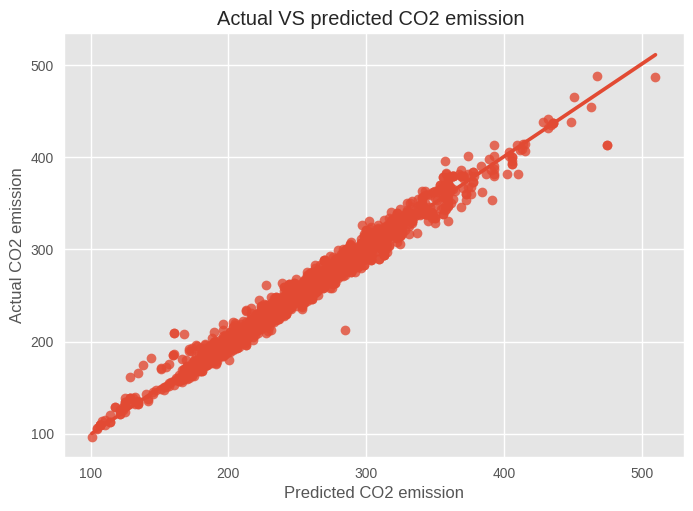

In [176]:
sns.regplot(x=predictions, y=y_test)
plt.xlabel ('Predicted CO2 emission')
plt.ylabel ('Actual CO2 emission')
plt.title('Actual VS predicted CO2 emission ')
plt.show()

In [157]:
df.head()

,Make,Model,Vehicle Class,Engine Size(L),Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
0,ACURA,ILX,COMPACT,2.0,AS5,Z,9.9,6.7,8.5,33,196
1,ACURA,ILX,COMPACT,2.4,M6,Z,11.2,7.7,9.6,29,221
2,ACURA,ILX HYBRID,COMPACT,1.5,AV7,Z,6.0,5.8,5.9,48,136
3,ACURA,MDX 4WD,SUV - SMALL,3.5,AS6,Z,12.7,9.1,11.1,25,255
4,ACURA,RDX AWD,SUV - SMALL,3.5,AS6,Z,12.1,8.7,10.6,27,244


<Axes: xlabel='Fuel Consumption City (L/100 km)', ylabel='CO2 Emissions(g/km)'>

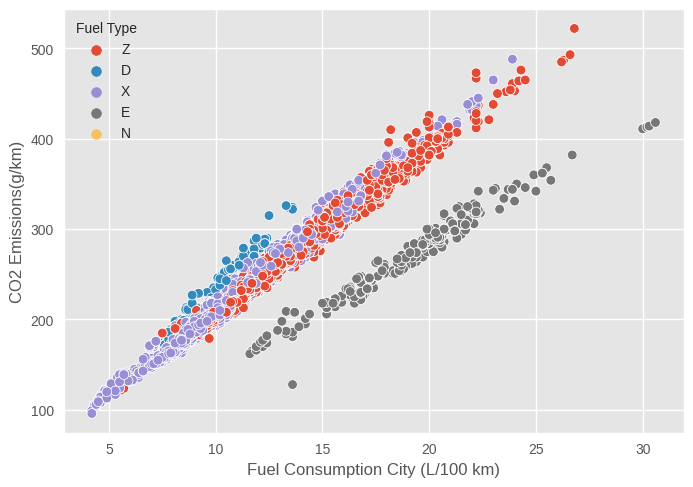

In [158]:
sns.scatterplot(x = df["Fuel Consumption City (L/100 km)"], y = df["CO2 Emissions(g/km)"], hue ="Fuel Type", data = df)

In above obsevation, i can analys the points are color-coded by fuel type. this exaplins why prevouse simple linear regression and a "secondary line" of points:
- Ethanol(E) : The Gray points: These sit much lower than the rest. Ethanol has lower enerty density, so cars burn more of it (higher X-axis value), but it produces significantly less CO2 per liter burned (Lower y-axis value).
- Disel(D) - The Blue points: these sit slightly higher than the main group. Diesal is more carbon-intensive than regular gasoline.
- regualr(X) and premium (Z): These form the dense "main" red/purple cluster in the middle. 

<Axes: xlabel='Engine Size(L)', ylabel='CO2 Emissions(g/km)'>

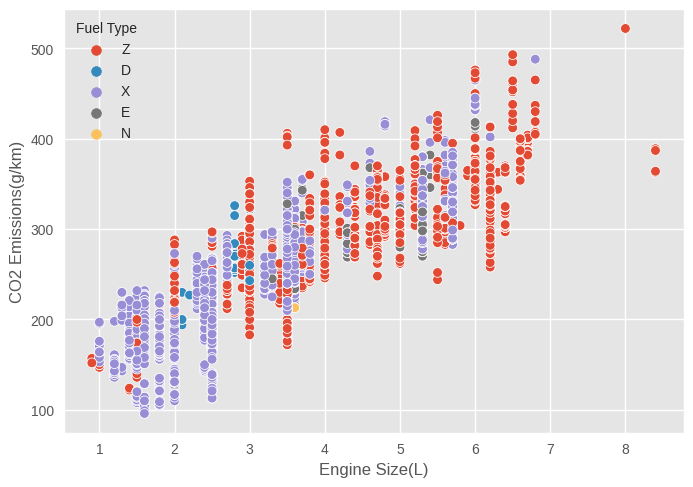

In [159]:
sns.scatterplot(x = df["Engine Size(L)"], y = df["CO2 Emissions(g/km)"], hue ="Fuel Type", data = df)

In [160]:
# Using the best predictor + the fuel type modifier
X = df_2[["Fuel Consumption City (L/100 km)", "Fuel_Type_encoded"]]
y = df_2["CO2 Emissions(g/km)"]

# Split and Train
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
lr = LinearRegression()
model = lr.fit(X_train, y_train)

# Evaluate
predictions = model.predict(X_test)
print('New R2 Score:', r2_score(y_test, predictions))

print('New RMSE:', np.sqrt(mean_squared_error(y_test, predictions)))

New R2 Score: 0.8629565491715376
New RMSE: 21.514934876559344


In [169]:
# Create the encoder (sparse_output=False makes it a dense array you can read)
ohe = OneHotEncoder(sparse_output=False)
Fuel_Type_oh = ohe.fit_transform(df[["Fuel Type"]])

# Create a DataFrame with the new column names (D, E, N, X, Z)
fuel_df = pd.DataFrame(Fuel_Type_oh, columns=ohe.get_feature_names_out(['Fuel Type']))

# Join it back to your main data
df_final = pd.concat([df_2, fuel_df], axis=1)

In [171]:
df_final

,Engine Size(L),Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km),Transmission_encoded,Vehicle_Class_encoded,Fuel_Type_encoded,Fuel Type_D,Fuel Type_E,Fuel Type_N,Fuel Type_X,Fuel Type_Z
0,2.0,9.9,6.7,8.5,33,196,0,0,0,0.0,0.0,0.0,0.0,1.0
1,2.4,11.2,7.7,9.6,29,221,1,0,0,0.0,0.0,0.0,0.0,1.0
2,1.5,6.0,5.8,5.9,48,136,2,0,0,0.0,0.0,0.0,0.0,1.0
3,3.5,12.7,9.1,11.1,25,255,3,1,0,0.0,0.0,0.0,0.0,1.0
4,3.5,12.1,8.7,10.6,27,244,3,1,0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7380,2.0,10.7,7.7,9.4,30,219,8,1,0,0.0,0.0,0.0,0.0,1.0
7381,2.0,11.2,8.3,9.9,29,232,8,1,0,0.0,0.0,0.0,0.0,1.0
7382,2.0,11.7,8.6,10.3,27,240,8,1,0,0.0,0.0,0.0,0.0,1.0
7383,2.0,11.2,8.3,9.9,29,232,8,8,0,0.0,0.0,0.0,0.0,1.0


In [174]:
features = [
    'Fuel Consumption City (L/100 km)', 
    'Fuel Type_D', 'Fuel Type_E', 'Fuel Type_N', 'Fuel Type_X', 'Fuel Type_Z'
]

X = df_final[features]
y = df_final['CO2 Emissions(g/km)']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


lr_ohe = LinearRegression()
lr_ohe.fit(X_train, y_train)


predictions = lr_ohe.predict(X_test)

print('--- One-Hot Encoding Model Results ---')
print('New R2 Score:', r2_score(y_test, predictions))
print('New RMSE:', np.sqrt(mean_squared_error(y_test, predictions)))
print('New MAE:', mean_absolute_error(y_test, predictions))

--- One-Hot Encoding Model Results ---
New R2 Score: 0.9781467343272515
New RMSE: 8.591501409852054
New MAE: 6.352425617346228


In [182]:
# Training set par prediction karein
train_preds = lr_ohe.predict(X_train)

# Dono scores calculate karein
train_r2 = r2_score(y_train, train_preds)
test_r2 = r2_score(y_test, predictions) # 'predictions' pehle se test set par hain

print(f"Training R2 Score: {train_r2:.4f}")
print(f"Testing R2 Score: {test_r2:.4f}")

# Difference check karein
diff = train_r2 - test_r2
print(f"Difference: {diff:.4f}")

Training R2 Score: 0.9793
Testing R2 Score: 0.9781
Difference: 0.0011
